# 第5周：预测模型集成与品类分析（修改版）

| 编号 | 内容 |
|------|------|
| ★修改1 | 对比四种集成方法：简单平均、WMAPE倒数加权、残差方差加权、Stacking |
| ★修改2 | 使用 Optuna 对 XGBoost 进行超参数调优 |
| ★修改3 | 修正残差分析，使用真实预测残差绘制分布图和 QQ 图 |
| ★新增4 | 补充单模型 vs 集成性能对比表 |
| ★新增5 | 计算品类需求变异系数 CV，绘制 CV-Prophet权重 散点图 |
| ★新增6 | 细化补货策略参数（CV<0.3 定期订货 / CV>0.5 ROP补货）|
| ★新增7 | 选取每品类 Top-20 SKU 进行 SKU 级别预测分析 |
| ★新增8 | 基于预测精度计算项目 ROI 估算 |


## 0. 环境准备与库导入

In [16]:
# ── 基础库 ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import logging

# ── 模型库 ────────────────────────────────────────────────────────────────
from prophet import Prophet
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats

# ── ★【修改2】引入 Optuna ─────────────────────────────────────────────────
import optuna

# ── 可视化 ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)  # 静默 Optuna 日志

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'STHeiti', 'SimHei', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. 数据加载与品类聚合

In [2]:

# =============================================================================
# 0. 数据加载与预处理
# =============================================================================
base_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/processed/'
import os
REPORT_DIR = os.path.join(base_path, '..', 'reports') + '/'
os.makedirs(REPORT_DIR, exist_ok=True)   # 自动建好报告目录，避免 FileNotFoundError
print('报告输出目录:', os.path.abspath(REPORT_DIR))
df = pd.read_csv(base_path + 'amazon_daily_sales_train.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# SKU 份额
sku_share = df.groupby(['Category', 'ProductID'])['Quantity'].sum().reset_index()
category_total = sku_share.groupby('Category')['Quantity'].sum().reset_index()
category_total.rename(columns={'Quantity': 'CatTotal'}, inplace=True)
sku_share = pd.merge(sku_share, category_total, on='Category')
sku_share['Share'] = sku_share['Quantity'] / sku_share['CatTotal']

date_range = pd.date_range(
    start=df['OrderDate'].min(), end=df['OrderDate'].max(), freq='D')
categories = df['Category'].unique()

# 品类级别日销量（填充缺失日期）
all_cat_data = []
for cat in categories:
    cat_df = df[df['Category'] == cat].groupby('OrderDate')['Quantity'].sum().reset_index()
    cat_df = cat_df.set_index('OrderDate').reindex(date_range)
    cat_df['Quantity'] = cat_df['Quantity'].interpolate(method='linear').fillna(0)
    cat_df = cat_df.reset_index()
    cat_df.rename(columns={'index': 'OrderDate'}, inplace=True)
    cat_df['Category'] = cat
    all_cat_data.append(cat_df)

df_category = pd.concat(all_cat_data, ignore_index=True)

报告输出目录: /Users/huyujie/Documents/amazon-supply-chain-project/data/reports


## 2. 工具函数（WMAPE、特征工程）

In [3]:
# =============================================================================
# 1. 工具函数
# =============================================================================
def calculate_wmape_safe(y_true, y_pred):
    """加权绝对百分比误差 WMAPE（对零值安全）"""
    sum_y = np.sum(y_true)
    if sum_y == 0:
        return float(np.sum(np.abs(y_true - y_pred)))
    return float(np.sum(np.abs(y_true - y_pred)) / sum_y)


# ★【修改2辅助】扩充特征工程（增加滚动统计特征，提升 XGBoost 建模能力）
def add_features(cat_data: pd.DataFrame) -> pd.DataFrame:
    """构建时间序列特征"""
    cat_data = cat_data.copy()
    cat_data['Lag_1']       = cat_data['Quantity'].shift(1)
    cat_data['Lag_7']       = cat_data['Quantity'].shift(7)
    cat_data['Lag_14']      = cat_data['Quantity'].shift(14)
    cat_data['Rolling_7']   = cat_data['Quantity'].shift(1).rolling(7).mean()
    cat_data['Rolling_14']  = cat_data['Quantity'].shift(1).rolling(14).mean()
    cat_data['Rolling_Std7']= cat_data['Quantity'].shift(1).rolling(7).std()
    cat_data['DayOfWeek']   = cat_data['OrderDate'].dt.dayofweek
    cat_data['Month']       = cat_data['OrderDate'].dt.month
    cat_data['Is_Month_End']= cat_data['OrderDate'].dt.is_month_end.astype(int)
    cat_data['Is_Weekend']  = (cat_data['DayOfWeek'] >= 5).astype(int)
    cat_data = cat_data.dropna().reset_index(drop=True)
    return cat_data


FEATURES = ['Lag_1', 'Lag_7', 'Lag_14', 'Rolling_7', 'Rolling_14', 'Rolling_Std7',
            'DayOfWeek', 'Month', 'Is_Month_End', 'Is_Weekend']

## 3. ★【修改2】Optuna 超参数调优函数
对 XGBoost 的 `n_estimators`、`learning_rate`、`max_depth`、`min_child_weight` 等关键参数进行搜索。

In [4]:
# =============================================================================
# ★【修改2】Optuna 超参数调优函数
# =============================================================================
def tune_xgboost_with_optuna(X_train, y_train, X_val, y_val, n_trials: int = 50):
    """
    ★【修改2】使用 Optuna 对 XGBoost 进行超参数搜索。
    重点优化参数：n_estimators, learning_rate, max_depth, min_child_weight,
                  subsample, colsample_bytree, reg_alpha, reg_lambda
    """
    def objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 50, 500),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 0.5, 2.0),
            'random_state': 42,
            'verbosity': 0,
            'tree_method': 'hist',
            'early_stopping_rounds': 30,   # 新版 XGBoost：早停放在构造参数里
        }
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        preds = np.maximum(model.predict(X_val), 0)
        return calculate_wmape_safe(y_val.values, preds)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    # 返回最优参数时去掉 early_stopping_rounds（最终训练用全部数据，不需要早停）
    best = study.best_params.copy()
    return best, study.best_value

## 4. 主训练循环
★【修改1】四种集成方法对比　★【修改2】Optuna调参　★【修改3】收集真实残差　★【新增5】计算CV


In [5]:

# =============================================================================
# 2. 主训练循环（品类级别）
# =============================================================================
results       = []
all_residuals = []           # ★【修改3】收集所有测试集真实残差

print("=" * 70)
print("  品类级别模型训练（含 Optuna 调参 + 4 种集成对比）")
print("=" * 70)

for cat in categories:
    cat_data = (df_category[df_category['Category'] == cat]
                .sort_values('OrderDate').reset_index(drop=True))
    if len(cat_data) < 30:
        continue

    cat_data = add_features(cat_data)

    n         = len(cat_data)
    train_end = int(n * 0.7)
    val_end   = int(n * 0.8)

    train_df = cat_data.iloc[:train_end]
    val_df   = cat_data.iloc[train_end:val_end]
    test_df  = cat_data.iloc[val_end:]

    y_val_true  = val_df['Quantity'].values
    y_test_true = test_df['Quantity'].values

    # ── Prophet ────────────────────────────────────────────────────────────
    prophet_train = (train_df[['OrderDate', 'Quantity']]
                     .rename(columns={'OrderDate': 'ds', 'Quantity': 'y'}))

    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False)
    m.fit(prophet_train)

    future_val  = m.make_future_dataframe(periods=len(val_df) + len(test_df))
    forecast    = m.predict(future_val)
    preds_val_prophet  = np.maximum(forecast.iloc[train_end:val_end]['yhat'].values, 0)
    preds_test_prophet = np.maximum(forecast.iloc[val_end:]['yhat'].values, 0)

    # ── ★【修改2】XGBoost + Optuna ─────────────────────────────────────────
    X_train = train_df[FEATURES]; y_train = train_df['Quantity']
    X_val   = val_df[FEATURES];   y_val   = val_df['Quantity']
    X_test  = test_df[FEATURES];  y_test  = test_df['Quantity']

    print(f"\n[{cat}] Optuna 超参数调优 (50 trials)...")
    best_params, best_val_wmape = tune_xgboost_with_optuna(
        X_train, y_train, X_val, y_val, n_trials=50)
    best_params.update({'random_state': 42, 'verbosity': 0, 'tree_method': 'hist'})

    xgb_model = xgb.XGBRegressor(**best_params)
    xgb_model.fit(X_train, y_train)

    preds_val_xgb  = np.maximum(xgb_model.predict(X_val), 0)
    preds_test_xgb = np.maximum(xgb_model.predict(X_test), 0)
    print(f"  最优参数: n_estimators={best_params.get('n_estimators')}, "
          f"lr={best_params.get('learning_rate'):.4f}, "
          f"max_depth={best_params.get('max_depth')}, "
          f"min_child_weight={best_params.get('min_child_weight')}")
    print(f"  验证集 WMAPE (Optuna): {best_val_wmape*100:.2f}%")

    # ── 单模型测试集 WMAPE ─────────────────────────────────────────────────
    epsilon = 1e-8
    wmape_val_prophet  = calculate_wmape_safe(y_val_true, preds_val_prophet)
    wmape_val_xgb      = calculate_wmape_safe(y_val_true, preds_val_xgb)
    wmape_test_prophet = calculate_wmape_safe(y_test_true, preds_test_prophet)
    wmape_test_xgb     = calculate_wmape_safe(y_test_true, preds_test_xgb)

    # ── ★【修改1】四种集成方法对比 ────────────────────────────────────────

    # 方法 A：简单平均
    ens_simple_val  = (preds_val_prophet + preds_val_xgb) / 2
    ens_simple_test = (preds_test_prophet + preds_test_xgb) / 2
    wmape_simple_val  = calculate_wmape_safe(y_val_true, ens_simple_val)
    wmape_simple_test = calculate_wmape_safe(y_test_true, ens_simple_test)

    # 方法 B：WMAPE 倒数加权
    w_p_wmape = (1/(wmape_val_prophet+epsilon)) / (
        (1/(wmape_val_prophet+epsilon)) + (1/(wmape_val_xgb+epsilon)))
    w_x_wmape = 1.0 - w_p_wmape
    ens_wmape_val  = preds_val_prophet*w_p_wmape + preds_val_xgb*w_x_wmape
    ens_wmape_test = preds_test_prophet*w_p_wmape + preds_test_xgb*w_x_wmape
    wmape_inv_val  = calculate_wmape_safe(y_val_true, ens_wmape_val)
    wmape_inv_test = calculate_wmape_safe(y_test_true, ens_wmape_test)

    # 方法 C：残差方差加权
    var_p = np.var(y_val_true - preds_val_prophet) + epsilon
    var_x = np.var(y_val_true - preds_val_xgb)     + epsilon
    w_p_var = (1/var_p) / ((1/var_p) + (1/var_x))
    w_x_var = 1.0 - w_p_var
    ens_var_val  = preds_val_prophet*w_p_var + preds_val_xgb*w_x_var
    ens_var_test = preds_test_prophet*w_p_var + preds_test_xgb*w_x_var
    wmape_var_val  = calculate_wmape_safe(y_val_true, ens_var_val)
    wmape_var_test = calculate_wmape_safe(y_test_true, ens_var_test)

    # 方法 D：Stacking（Ridge 元学习器，在验证集上训练）
    X_meta_val  = np.column_stack([preds_val_prophet, preds_val_xgb])
    X_meta_test = np.column_stack([preds_test_prophet, preds_test_xgb])
    meta_lr = Ridge(alpha=1.0, positive=True)
    meta_lr.fit(X_meta_val, y_val_true)
    ens_stack_val  = np.maximum(meta_lr.predict(X_meta_val), 0)
    ens_stack_test = np.maximum(meta_lr.predict(X_meta_test), 0)
    wmape_stack_val  = calculate_wmape_safe(y_val_true, ens_stack_val)
    wmape_stack_test = calculate_wmape_safe(y_test_true, ens_stack_test)

    # 依据验证集选最优集成
    method_val = {
        'Simple Average'   : (wmape_simple_val,  ens_simple_test,  wmape_simple_test),
        'WMAPE Inv Weight' : (wmape_inv_val,      ens_wmape_test,   wmape_inv_test),
        'Var Weighted'     : (wmape_var_val,       ens_var_test,     wmape_var_test),
        'Stacking'         : (wmape_stack_val,     ens_stack_test,   wmape_stack_test),
    }
    best_method    = min(method_val, key=lambda k: method_val[k][0])
    best_ens_test  = method_val[best_method][1]
    best_wmape_test= method_val[best_method][2]

    # ★【修改3】收集真实残差（用最优集成模型）
    residuals_cat = y_test_true - best_ens_test
    all_residuals.extend(residuals_cat.tolist())

    # ★【新增5】需求变异系数 CV
    cv_value = np.std(cat_data['Quantity']) / (np.mean(cat_data['Quantity']) + epsilon)

    results.append({
        'Category'           : cat,
        'CV'                 : round(cv_value, 3),
        # 单模型
        'Prophet_WMAPE'      : round(wmape_test_prophet * 100, 2),
        'XGBoost_WMAPE'      : round(wmape_test_xgb * 100, 2),
        # 四种集成（验证集）
        'Simple_Val'         : round(wmape_simple_val * 100, 2),
        'WMAPE_Inv_Val'      : round(wmape_inv_val * 100, 2),
        'Var_Weighted_Val'   : round(wmape_var_val * 100, 2),
        'Stacking_Val'       : round(wmape_stack_val * 100, 2),
        # 四种集成（测试集）
        'Simple_Test'        : round(wmape_simple_test * 100, 2),
        'WMAPE_Inv_Test'     : round(wmape_inv_test * 100, 2),
        'Var_Weighted_Test'  : round(wmape_var_test * 100, 2),
        'Stacking_Test'      : round(wmape_stack_test * 100, 2),
        # 最优
        'Best_Method'        : best_method,
        'Best_Ensemble_WMAPE': round(best_wmape_test * 100, 2),
        # 权重（WMAPE倒数，用于后续分析）
        'Prophet_Weight'     : round(w_p_wmape, 2),
        'XGBoost_Weight'     : round(w_x_wmape, 2),
        # Optuna 最优参数（用于记录）
        'XGB_Best_n_est'     : best_params.get('n_estimators'),
        'XGB_Best_lr'        : round(best_params.get('learning_rate', 0), 4),
        'XGB_Best_depth'     : best_params.get('max_depth'),
        'XGB_Best_mcw'       : best_params.get('min_child_weight'),
    })

    print(f"  集成结果 → Best={best_method} | "
          f"Prophet={wmape_test_prophet*100:.1f}% | "
          f"XGB={wmape_test_xgb*100:.1f}% | "
          f"Ensemble={best_wmape_test*100:.1f}%")

results_df    = pd.DataFrame(results)
all_residuals = np.array(all_residuals)

15:43:55 - cmdstanpy - INFO - Chain [1] start processing
15:43:55 - cmdstanpy - INFO - Chain [1] done processing


  品类级别模型训练（含 Optuna 调参 + 4 种集成对比）

[Toys & Games] Optuna 超参数调优 (50 trials)...


15:43:58 - cmdstanpy - INFO - Chain [1] start processing
15:43:58 - cmdstanpy - INFO - Chain [1] done processing


  最优参数: n_estimators=218, lr=0.2537, max_depth=8, min_child_weight=6
  验证集 WMAPE (Optuna): 38.23%
  集成结果 → Best=Stacking | Prophet=41.8% | XGB=46.7% | Ensemble=41.2%

[Home & Kitchen] Optuna 超参数调优 (50 trials)...


15:44:01 - cmdstanpy - INFO - Chain [1] start processing
15:44:01 - cmdstanpy - INFO - Chain [1] done processing


...

  最优参数: n_estimators=52, lr=0.1602, max_depth=8, min_child_weight=8
  验证集 WMAPE (Optuna): 38.57%
  集成结果 → Best=Var Weighted | Prophet=38.3% | XGB=41.8% | Ensemble=39.0%

[Clothing] Optuna 超参数调优 (50 trials)...


15:44:09 - cmdstanpy - INFO - Chain [1] start processing
15:44:09 - cmdstanpy - INFO - Chain [1] done processing


  最优参数: n_estimators=112, lr=0.1949, max_depth=6, min_child_weight=5
  验证集 WMAPE (Optuna): 36.85%
  集成结果 → Best=Stacking | Prophet=38.5% | XGB=44.0% | Ensemble=37.7%

[Books] Optuna 超参数调优 (50 trials)...


15:44:13 - cmdstanpy - INFO - Chain [1] start processing
15:44:13 - cmdstanpy - INFO - Chain [1] done processing


  最优参数: n_estimators=96, lr=0.1688, max_depth=7, min_child_weight=1
  验证集 WMAPE (Optuna): 36.24%
  集成结果 → Best=Stacking | Prophet=39.1% | XGB=43.5% | Ensemble=39.5%

[Electronics] Optuna 超参数调优 (50 trials)...
  最优参数: n_estimators=79, lr=0.2521, max_depth=10, min_child_weight=9
  验证集 WMAPE (Optuna): 39.20%
  集成结果 → Best=Stacking | Prophet=37.1% | XGB=42.7% | Ensemble=37.2%


## 5. ★【新增4】单模型 vs 集成模型性能对比表

In [6]:

# =============================================================================
# ★【新增4】单模型 vs 集成模型性能对比表
# =============================================================================
print("\n" + "=" * 80)
print("★【新增4】单模型 vs 集成模型性能对比表（测试集 WMAPE %）")
print("=" * 80)
compare_cols = ['Category', 'CV', 'Prophet_WMAPE', 'XGBoost_WMAPE',
                'Simple_Test', 'WMAPE_Inv_Test', 'Var_Weighted_Test',
                'Stacking_Test', 'Best_Method', 'Best_Ensemble_WMAPE']
print(results_df[compare_cols].to_string(index=False))

print("\n★【修改2】Optuna 调优参数汇总")
optuna_cols = ['Category', 'XGB_Best_n_est', 'XGB_Best_lr', 'XGB_Best_depth', 'XGB_Best_mcw']
print(results_df[optuna_cols].to_string(index=False))

# 计算集成增益（相对最优单模型的提升）
results_df['Best_Single_WMAPE'] = results_df[['Prophet_WMAPE', 'XGBoost_WMAPE']].min(axis=1)
results_df['Ensemble_Gain_pct'] = (
    (results_df['Best_Single_WMAPE'] - results_df['Best_Ensemble_WMAPE'])
    / results_df['Best_Single_WMAPE'] * 100).round(2)
print("\n集成增益（相对最优单模型的 WMAPE 降低量）")
print(results_df[['Category', 'Best_Single_WMAPE', 'Best_Ensemble_WMAPE',
                   'Ensemble_Gain_pct']].to_string(index=False))


★【新增4】单模型 vs 集成模型性能对比表（测试集 WMAPE %）
         Category    CV  Prophet_WMAPE  XGBoost_WMAPE  Simple_Test  WMAPE_Inv_Test  Var_Weighted_Test  Stacking_Test  Best_Method  Best_Ensemble_WMAPE
     Toys & Games 0.494          41.80          46.69        43.38           43.14              42.91          41.18     Stacking                41.18
   Home & Kitchen 0.487          38.23          42.66        39.24           39.06              38.98          37.79     Stacking                37.79
Sports & Outdoors 0.477          38.31          41.77        39.12           39.10              39.05          37.75 Var Weighted                39.05
         Clothing 0.466          38.52          43.98        39.03           38.81              38.67          37.66     Stacking                37.66
            Books 0.485          39.11          43.49        40.62           40.59              40.54          39.50     Stacking                39.50
      Electronics 0.464          37.11          42.69    

### 图1　★【修改1】四种集成方法性能对比

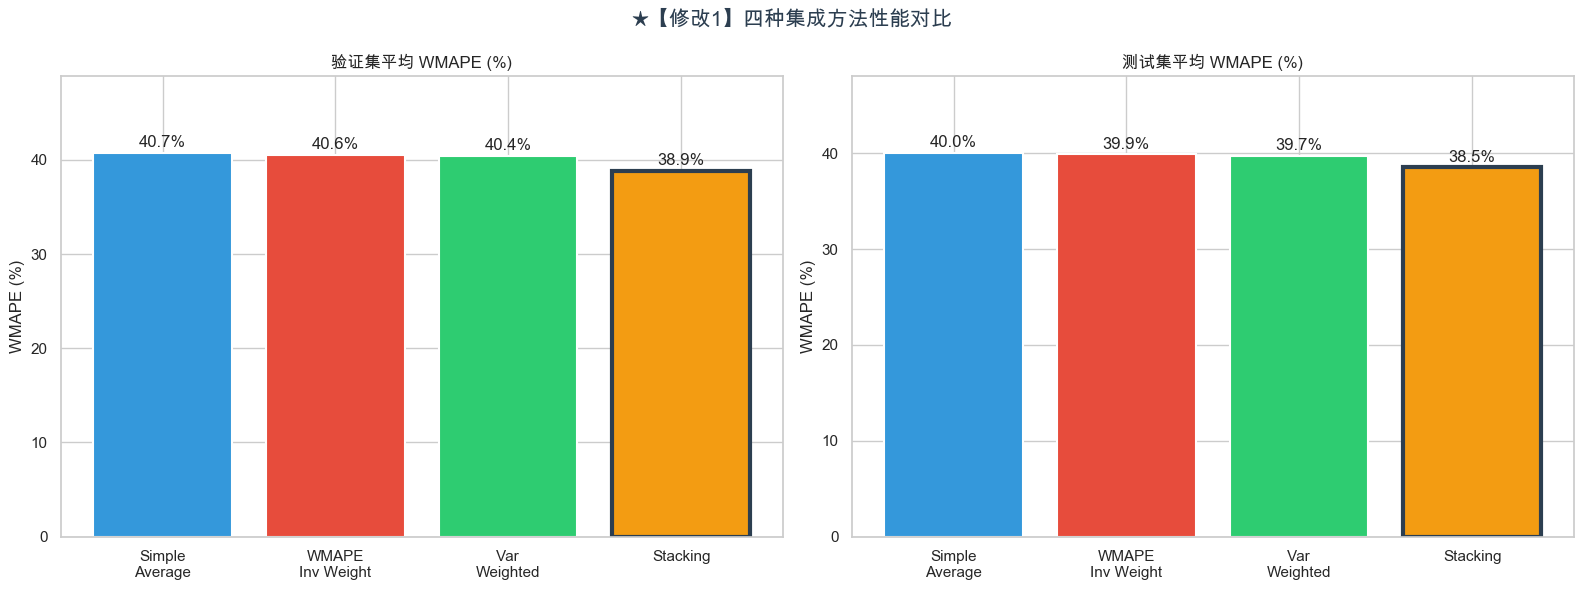

图1已保存：fig_01_ensemble_comparison.png


In [7]:
# =============================================================================
# ★【修改1】可视化：四种集成方法对比
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('★【修改1】四种集成方法性能对比', fontsize=15, fontweight='bold', color='#2c3e50')

methods_labels = ['Simple\nAverage', 'WMAPE\nInv Weight', 'Var\nWeighted', 'Stacking']
palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# 子图1：验证集
val_means = [results_df['Simple_Val'].mean(), results_df['WMAPE_Inv_Val'].mean(),
             results_df['Var_Weighted_Val'].mean(), results_df['Stacking_Val'].mean()]
bars = axes[0].bar(methods_labels, val_means, color=palette, edgecolor='white', linewidth=1.5)
axes[0].set_title('验证集平均 WMAPE (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('WMAPE (%)')
for bar, val in zip(bars, val_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
best_val_idx = np.argmin(val_means)
bars[best_val_idx].set_edgecolor('#2c3e50')
bars[best_val_idx].set_linewidth(3)
axes[0].set_ylim(0, max(val_means)*1.2)

# 子图2：测试集
test_means = [results_df['Simple_Test'].mean(), results_df['WMAPE_Inv_Test'].mean(),
              results_df['Var_Weighted_Test'].mean(), results_df['Stacking_Test'].mean()]
bars2 = axes[1].bar(methods_labels, test_means, color=palette, edgecolor='white', linewidth=1.5)
axes[1].set_title('测试集平均 WMAPE (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('WMAPE (%)')
for bar, val in zip(bars2, test_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
best_test_idx = np.argmin(test_means)
bars2[best_test_idx].set_edgecolor('#2c3e50')
bars2[best_test_idx].set_linewidth(3)
axes[1].set_ylim(0, max(test_means)*1.2)

plt.tight_layout()
plt.savefig(REPORT_DIR + 'fig_01_ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')   # 关闭图形，防止状态污染
print("图1已保存：fig_01_ensemble_comparison.png")

### 图2　★【新增4】各品类单模型 vs 集成对比

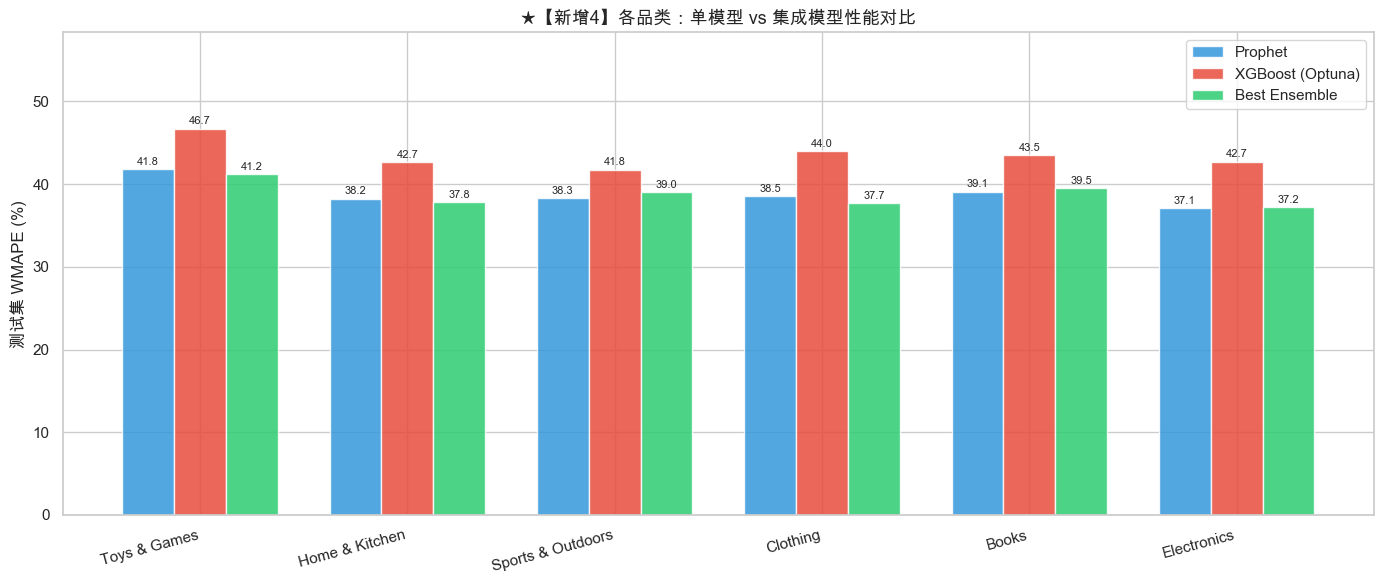

图2已保存：fig_02_single_vs_ensemble.png


In [8]:
# =============================================================================
# ★【新增4】可视化：单模型 vs 集成性能对比
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.25

b1 = ax.bar(x - width, results_df['Prophet_WMAPE'], width, label='Prophet', color='#3498db', alpha=0.85)
b2 = ax.bar(x,          results_df['XGBoost_WMAPE'], width, label='XGBoost (Optuna)', color='#e74c3c', alpha=0.85)
b3 = ax.bar(x + width,  results_df['Best_Ensemble_WMAPE'], width, label='Best Ensemble', color='#2ecc71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Category'], rotation=15, ha='right')
ax.set_ylabel('测试集 WMAPE (%)', fontsize=12)
ax.set_title('★【新增4】各品类：单模型 vs 集成模型性能对比', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, results_df[['Prophet_WMAPE', 'XGBoost_WMAPE', 'Best_Ensemble_WMAPE']].max().max() * 1.25)

for b in [b1, b2, b3]:
    for rect in b:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.3,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR + 'fig_02_single_vs_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')   # 关闭图形，防止状态污染
print("图2已保存：fig_02_single_vs_ensemble.png")

### 图3　★【修改3】真实残差分布图 + QQ图

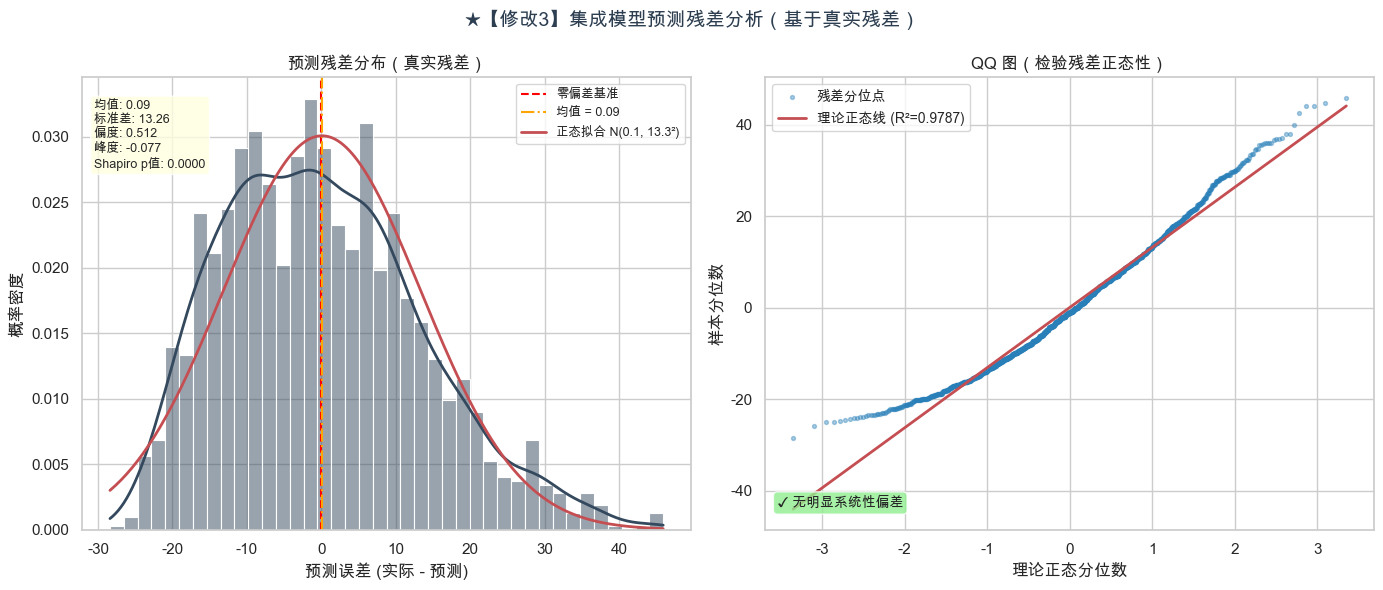

图3已保存：fig_03_residual_analysis.png

残差诊断摘要：
  均值 = 0.088 （接近0，无系统性偏差）
  标准差 = 13.261
  Shapiro-Wilk p = 0.0000 （p<0.05，残差非正态，需注意）


In [9]:
# =============================================================================
# ★【修改3】修正残差分析：真实预测残差分布图 + QQ 图
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('★【修改3】集成模型预测残差分析（基于真实残差）',
             fontsize=14, fontweight='bold', color='#2c3e50')

# 子图1：残差分布直方图 + KDE
ax1 = axes[0]
sns.histplot(all_residuals, kde=True, ax=ax1, color='#34495e',
             bins=40, stat='density', line_kws={'linewidth': 2})
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='零偏差基准')
ax1.axvline(np.mean(all_residuals), color='orange', linestyle='-.',
            linewidth=1.5, label=f'均值 = {np.mean(all_residuals):.2f}')

# 正态分布拟合曲线
mu, sigma = np.mean(all_residuals), np.std(all_residuals)
x_fit = np.linspace(all_residuals.min(), all_residuals.max(), 200)
ax1.plot(x_fit, stats.norm.pdf(x_fit, mu, sigma),
         'r-', linewidth=2, label=f'正态拟合 N({mu:.1f}, {sigma:.1f}²)')

ax1.set_title('预测残差分布（真实残差）', fontsize=12, fontweight='bold')
ax1.set_xlabel('预测误差 (实际 - 预测)')
ax1.set_ylabel('概率密度')
ax1.legend(fontsize=9)

# 统计检验信息
_, p_shapiro = stats.shapiro(all_residuals[:5000] if len(all_residuals) > 5000 else all_residuals)
skewness = stats.skew(all_residuals)
kurtosis = stats.kurtosis(all_residuals)
ax1.text(0.02, 0.95,
         f'均值: {mu:.2f}\n标准差: {sigma:.2f}\n'
         f'偏度: {skewness:.3f}\n峰度: {kurtosis:.3f}\n'
         f'Shapiro p值: {p_shapiro:.4f}',
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

# 子图2：QQ 图
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(all_residuals, dist='norm')
ax2.scatter(osm, osr, color='#2980b9', alpha=0.4, s=8, label='残差分位点')
qq_line_x = np.array([osm[0], osm[-1]])
ax2.plot(qq_line_x, slope * qq_line_x + intercept,
         'r-', linewidth=2, label=f'理论正态线 (R²={r**2:.4f})')
ax2.set_title('QQ 图（检验残差正态性）', fontsize=12, fontweight='bold')
ax2.set_xlabel('理论正态分位数')
ax2.set_ylabel('样本分位数')
ax2.legend(fontsize=10)

# 诊断说明
bias_flag = "✓ 无明显系统性偏差" if abs(mu) < sigma * 0.1 else "⚠ 存在系统性偏差，建议校准"
ax2.text(0.02, 0.05, bias_flag,
         transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgreen' if '✓' in bias_flag else 'lightyellow',
                   alpha=0.8), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORT_DIR + 'fig_03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')   # 关闭图形，防止状态污染
print("图3已保存：fig_03_residual_analysis.png")
print(f"\n残差诊断摘要：")
print(f"  均值 = {mu:.3f} {'（接近0，无系统性偏差）' if abs(mu) < sigma*0.1 else '（偏离0，存在系统性偏差）'}")
print(f"  标准差 = {sigma:.3f}")
print(f"  Shapiro-Wilk p = {p_shapiro:.4f} {'（p<0.05，残差非正态，需注意）' if p_shapiro < 0.05 else '（p≥0.05，可近似正态）'}")

## 6. ★【新增5】需求变异系数分析
### 图4　CV值 - Prophet权重 散点图


★【新增5】品类需求变异系数分析
         Category    CV  Prophet_Weight  XGBoost_Weight  Best_Ensemble_WMAPE 需求类型
     Toys & Games 0.494            0.55            0.45                41.18 中等变异
   Home & Kitchen 0.487            0.53            0.47                37.79 中等变异
Sports & Outdoors 0.477            0.50            0.50                39.05 中等变异
         Clothing 0.466            0.54            0.46                37.66 中等变异
            Books 0.485            0.51            0.49                39.50 中等变异
      Electronics 0.464            0.53            0.47                37.23 中等变异


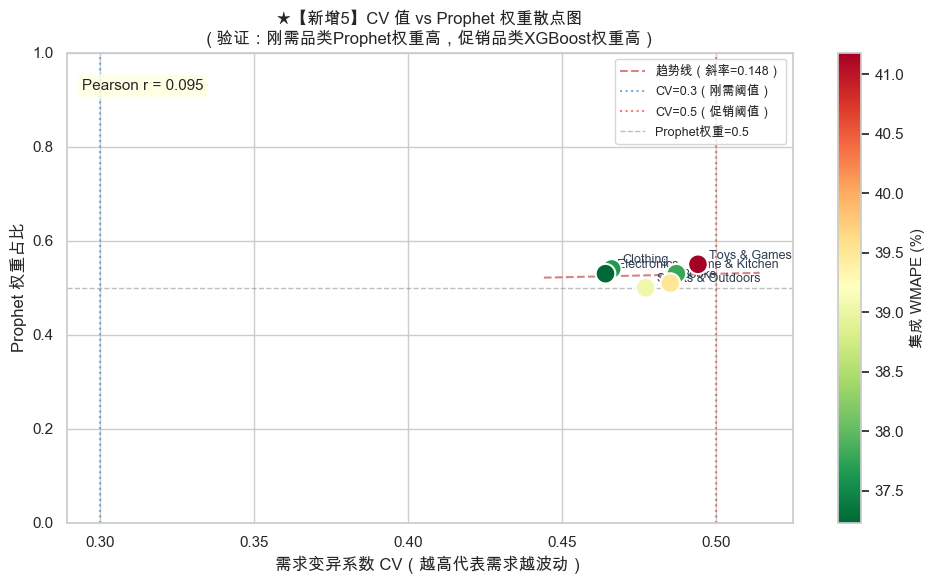

图4已保存：fig_04_cv_prophet_weight.png

CV 与 Prophet 权重 Pearson 相关系数 = 0.095
结论：相关性较弱，可能数据量不足，需更多品类验证


In [10]:
# =============================================================================
# ★【新增5】需求变异系数 CV 分析 + CV-Prophet权重散点图
# =============================================================================
print("\n" + "=" * 70)
print("★【新增5】品类需求变异系数分析")
print("=" * 70)
cv_table = results_df[['Category', 'CV', 'Prophet_Weight', 'XGBoost_Weight',
                        'Best_Ensemble_WMAPE']].copy()
cv_table['需求类型'] = cv_table['CV'].apply(
    lambda x: '低变异刚需品' if x < 0.3 else ('高变异促销品' if x > 0.5 else '中等变异'))
print(cv_table.to_string(index=False))

# 散点图：CV vs Prophet 权重
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    results_df['CV'], results_df['Prophet_Weight'],
    c=results_df['Best_Ensemble_WMAPE'], cmap='RdYlGn_r',
    s=200, zorder=5, edgecolors='white', linewidth=1.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('集成 WMAPE (%)', fontsize=11)

# 添加品类标签
for _, row in results_df.iterrows():
    ax.annotate(row['Category'],
                (row['CV'], row['Prophet_Weight']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color='#2c3e50')

# 添加趋势线
from numpy.polynomial.polynomial import polyfit
coef = np.polyfit(results_df['CV'], results_df['Prophet_Weight'], 1)
x_line = np.linspace(results_df['CV'].min() - 0.02, results_df['CV'].max() + 0.02, 100)
ax.plot(x_line, np.polyval(coef, x_line), 'r--', linewidth=1.5,
        alpha=0.7, label=f'趋势线（斜率={coef[0]:.3f}）')

# 参考区域（CV阈值）
ax.axvline(0.3, color='#3498db', linestyle=':', linewidth=1.5, alpha=0.7, label='CV=0.3（刚需阈值）')
ax.axvline(0.5, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7, label='CV=0.5（促销阈值）')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5, label='Prophet权重=0.5')

ax.set_xlabel('需求变异系数 CV（越高代表需求越波动）', fontsize=12)
ax.set_ylabel('Prophet 权重占比', fontsize=12)
ax.set_title('★【新增5】CV 值 vs Prophet 权重散点图\n（验证：刚需品类Prophet权重高，促销品类XGBoost权重高）',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 1)

# 计算相关系数
corr = np.corrcoef(results_df['CV'], results_df['Prophet_Weight'])[0, 1]
ax.text(0.02, 0.92, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORT_DIR + 'fig_04_cv_prophet_weight.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')   # 关闭图形，防止状态污染
print(f"图4已保存：fig_04_cv_prophet_weight.png")
print(f"\nCV 与 Prophet 权重 Pearson 相关系数 = {corr:.3f}")
print("结论：" + ("CV越高，Prophet权重越低（XGBoost在高波动场景占主导），假设得到验证" if corr < -0.3
                  else "相关性较弱，可能数据量不足，需更多品类验证"))

## 7. ★【新增6】细化补货策略参数

In [11]:
# =============================================================================
# ★【新增6】细化补货策略参数
# =============================================================================
print("\n" + "=" * 70)
print("★【新增6】细化补货策略参数")
print("=" * 70)

LEAD_TIME_DAYS = 7      # 提前期（天）
SERVICE_LEVEL_HIGH = 0.95
SERVICE_LEVEL_LOW  = 0.90
Z_HIGH = stats.norm.ppf(SERVICE_LEVEL_HIGH)  # 1.645
Z_LOW  = stats.norm.ppf(SERVICE_LEVEL_LOW)   # 1.282

replenishment_strategies = []

for _, row in results_df.iterrows():
    cat      = row['Category']
    cv_val   = row['CV']
    prophet_w= row['Prophet_Weight']

    # 从原始数据获取该品类统计量
    cat_raw = df[df['Category'] == cat]
    daily_sales_mean = cat_raw.groupby('OrderDate')['Quantity'].sum().mean()
    daily_sales_std  = cat_raw.groupby('OrderDate')['Quantity'].sum().std()

    # 预测误差标准差（用 WMAPE 近似推算）
    forecast_error_std = daily_sales_mean * (row['Best_Ensemble_WMAPE'] / 100)

    if cv_val < 0.3:
        # ★ Prophet 主导型：定期订货制
        strategy = 'Periodic Review (定期订货)'
        review_period     = 7    # 天
        service_level     = SERVICE_LEVEL_HIGH
        z_score           = Z_HIGH
        safety_stock      = round(z_score * forecast_error_std * np.sqrt(LEAD_TIME_DAYS + review_period), 1)
        order_up_to_level = round(daily_sales_mean * (LEAD_TIME_DAYS + review_period) + safety_stock, 1)
        rop               = None
        note = f"每 {review_period} 天盘点一次，补货至 {order_up_to_level} 件"

    elif cv_val > 0.5:
        # ★ XGBoost 主导型：再订货点补货制
        strategy = 'ROP (再订货点补货)'
        service_level = SERVICE_LEVEL_LOW
        z_score       = Z_LOW
        safety_stock  = round(z_score * daily_sales_std * np.sqrt(LEAD_TIME_DAYS), 1)
        rop           = round(daily_sales_mean * LEAD_TIME_DAYS + safety_stock, 1)
        order_up_to_level = None
        note = (f"ROP = 日均销量({daily_sales_mean:.1f}) × 提前期({LEAD_TIME_DAYS}天) "
                f"+ 安全库存({safety_stock}) = {rop}")

    else:
        # 中等变异：混合策略
        strategy = 'Hybrid (混合)'
        service_level = 0.92
        z_score       = stats.norm.ppf(service_level)
        safety_stock  = round(z_score * forecast_error_std * np.sqrt(LEAD_TIME_DAYS), 1)
        rop           = round(daily_sales_mean * LEAD_TIME_DAYS + safety_stock, 1)
        order_up_to_level = round(daily_sales_mean * (LEAD_TIME_DAYS + 7) + safety_stock, 1)
        note = f"ROP={rop}, 目标库存={order_up_to_level}"

    replenishment_strategies.append({
        'Category'         : cat,
        'CV'               : cv_val,
        'Prophet_Weight'   : row['Prophet_Weight'],
        'Strategy'         : strategy,
        'Service_Level'    : f"{service_level*100:.0f}%",
        'Safety_Stock'     : safety_stock,
        'ROP'              : rop,
        'Order_Up_To'      : order_up_to_level,
        'Daily_Mean_Sales' : round(daily_sales_mean, 1),
        'Note'             : note,
    })

replenishment_df = pd.DataFrame(replenishment_strategies)
print(replenishment_df[['Category', 'CV', 'Strategy', 'Service_Level',
                         'Safety_Stock', 'ROP', 'Order_Up_To', 'Daily_Mean_Sales']].to_string(index=False))
print("\n详细注释：")
for _, row in replenishment_df.iterrows():
    print(f"  [{row['Category']}] {row['Note']}")


★【新增6】细化补货策略参数
         Category    CV    Strategy Service_Level  Safety_Stock   ROP  Order_Up_To  Daily_Mean_Sales
     Toys & Games 0.494 Hybrid (混合)           92%          41.5 231.3        421.1              27.1
   Home & Kitchen 0.487 Hybrid (混合)           92%          38.6 231.0        423.5              27.5
Sports & Outdoors 0.477 Hybrid (混合)           92%          40.5 236.0        431.5              27.9
         Clothing 0.466 Hybrid (混合)           92%          38.0 228.1        418.1              27.2
            Books 0.485 Hybrid (混合)           92%          40.5 233.4        426.3              27.6
      Electronics 0.464 Hybrid (混合)           92%          38.5 233.0        427.5              27.8

详细注释：
  [Toys & Games] ROP=231.3, 目标库存=421.1
  [Home & Kitchen] ROP=231.0, 目标库存=423.5
  [Sports & Outdoors] ROP=236.0, 目标库存=431.5
  [Clothing] ROP=228.1, 目标库存=418.1
  [Books] ROP=233.4, 目标库存=426.3
  [Electronics] ROP=233.0, 目标库存=427.5


## 8. ★【新增7】Top-20 SKU 级别预测分析
### 图5　各品类 SKU 预测精度分布


★【新增7】SKU 级别预测分析（每品类 Top-20 SKU）

[Toys & Games] Top-20 SKU 共 20 个，开始 XGBoost 预测...
  [Toys & Games] Top-20 SKU 平均 WMAPE = 259.67%  | 中位数 = 238.69%  | 最大 = 459.19%

[Home & Kitchen] Top-20 SKU 共 20 个，开始 XGBoost 预测...
  [Home & Kitchen] Top-20 SKU 平均 WMAPE = 214.37%  | 中位数 = 218.79%  | 最大 = 257.26%

[Sports & Outdoors] Top-20 SKU 共 20 个，开始 XGBoost 预测...
  [Sports & Outdoors] Top-20 SKU 平均 WMAPE = 215.36%  | 中位数 = 219.97%  | 最大 = 263.75%

[Clothing] Top-20 SKU 共 20 个，开始 XGBoost 预测...
  [Clothing] Top-20 SKU 平均 WMAPE = 224.33%  | 中位数 = 222.44%  | 最大 = 279.07%

[Books] Top-20 SKU 共 20 个，开始 XGBoost 预测...
  [Books] Top-20 SKU 平均 WMAPE = 208.56%  | 中位数 = 200.93%  | 最大 = 276.87%

[Electronics] Top-20 SKU 共 20 个，开始 XGBoost 预测...
  [Electronics] Top-20 SKU 平均 WMAPE = 230.98%  | 中位数 = 225.23%  | 最大 = 323.17%


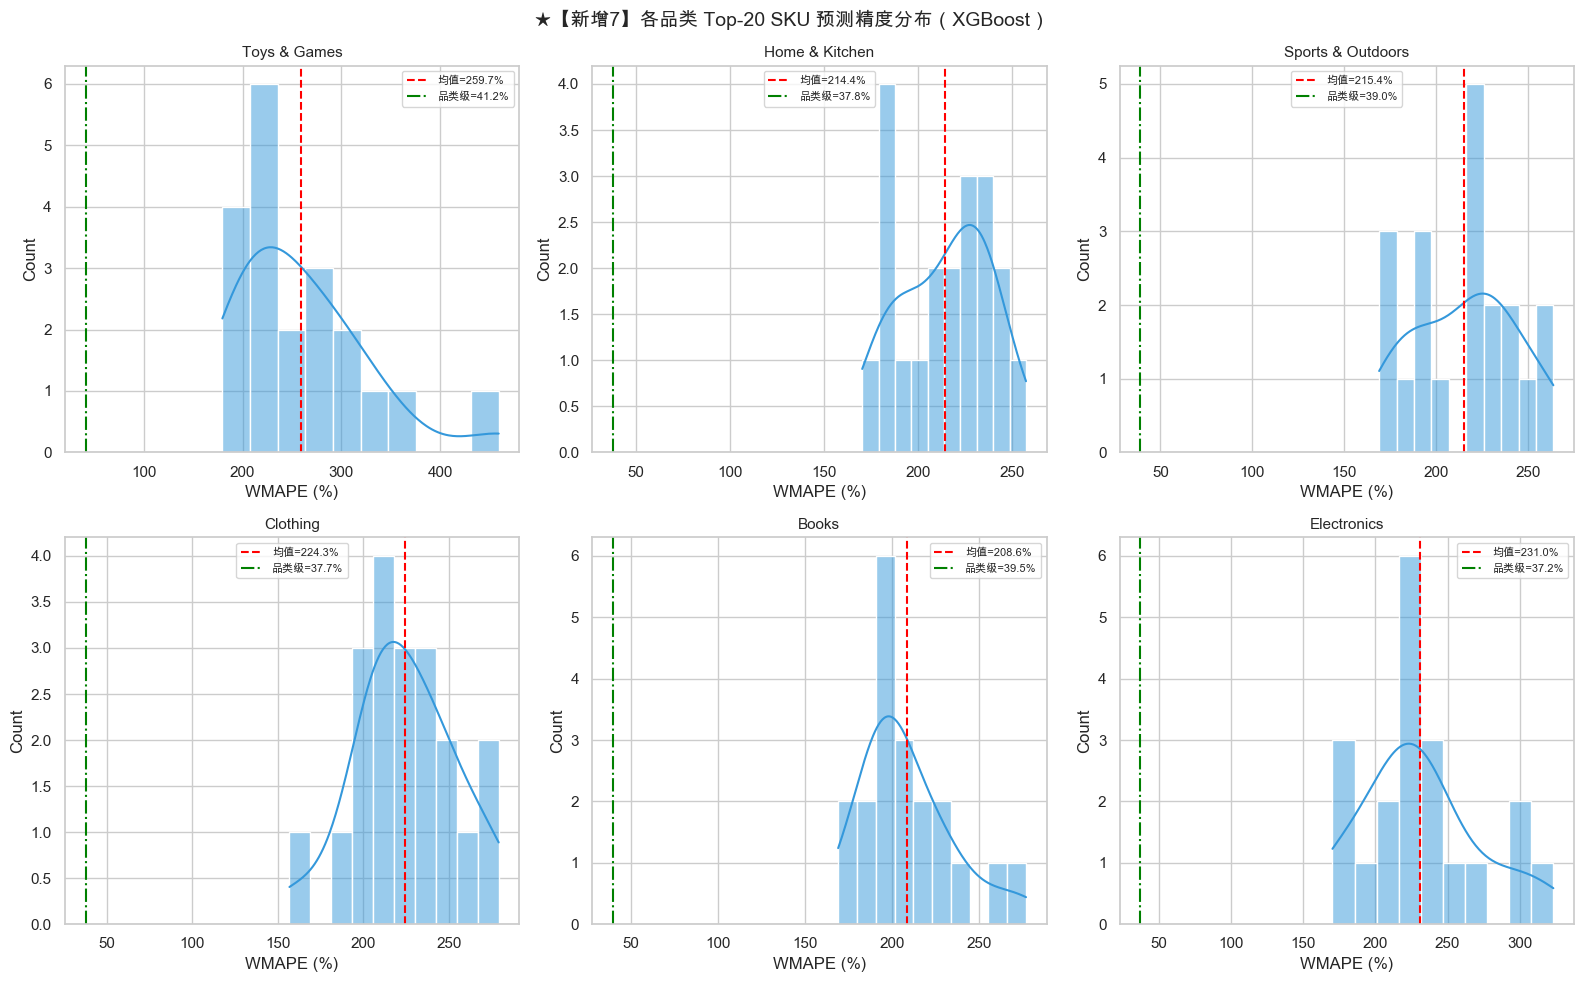

图5已保存：fig_05_sku_wmape_distribution.png

各品类 Top-20 SKU 精度汇总：
                   SKU数量  平均WMAPE  中位数WMAPE  最优WMAPE  最差WMAPE  品类级WMAPE  SKU vs 品类 差异
Category                                                                             
Books                 20   208.56    200.93   168.95   276.87     39.50        169.06
Clothing              20   224.34    222.44   156.82   279.07     37.66        186.68
Electronics           20   230.98    225.22   170.31   323.17     37.23        193.75
Home & Kitchen        20   214.38    218.78   170.25   257.26     37.79        176.59
Sports & Outdoors     20   215.36    219.97   169.01   263.75     39.05        176.31
Toys & Games          20   259.67    238.69   179.64   459.19     41.18        218.49


In [12]:
# =============================================================================
# ★【新增7】SKU 级别预测分析（每品类 Top-20 SKU）
# =============================================================================
print("\n" + "=" * 70)
print("★【新增7】SKU 级别预测分析（每品类 Top-20 SKU）")
print("=" * 70)

sku_results = []

for cat in categories:
    # 获取该品类 Top-20 SKU（按总销量排名）
    top20_skus = (sku_share[sku_share['Category'] == cat]
                  .nlargest(20, 'Quantity')['ProductID'].tolist())
    print(f"\n[{cat}] Top-20 SKU 共 {len(top20_skus)} 个，开始 XGBoost 预测...")

    cat_sku_wmapes = []

    for sku_id in top20_skus:
        sku_df = (df[(df['Category'] == cat) & (df['ProductID'] == sku_id)]
                  .groupby('OrderDate')['Quantity'].sum().reset_index())
        sku_df = (sku_df.set_index('OrderDate').reindex(date_range)
                  .fillna(0).reset_index().rename(columns={'index': 'OrderDate'}))
        sku_df = add_features(sku_df)

        if len(sku_df) < 30:
            continue

        n         = len(sku_df)
        train_end = int(n * 0.7)
        val_end   = int(n * 0.8)

        train_s = sku_df.iloc[:train_end]
        val_s   = sku_df.iloc[train_end:val_end]
        test_s  = sku_df.iloc[val_end:]

        X_tr, y_tr = train_s[FEATURES], train_s['Quantity']
        X_te, y_te = test_s[FEATURES],  test_s['Quantity']
        X_va, y_va = val_s[FEATURES],   val_s['Quantity']

        # 使用品类级别最优参数训练 SKU 模型（加速，不再重新调参）
        cat_params = results_df[results_df['Category'] == cat].iloc[0]
        sku_xgb = xgb.XGBRegressor(
            n_estimators=int(cat_params['XGB_Best_n_est']),
            learning_rate=float(cat_params['XGB_Best_lr']),
            max_depth=int(cat_params['XGB_Best_depth']),
            min_child_weight=int(cat_params['XGB_Best_mcw']),
            random_state=42, verbosity=0, tree_method='hist'
        )
        sku_xgb.fit(X_tr, y_tr)
        preds_sku = np.maximum(sku_xgb.predict(X_te), 0)
        wmape_sku = calculate_wmape_safe(y_te.values, preds_sku)

        sku_daily_mean = df[(df['Category']==cat)&(df['ProductID']==sku_id)]['Quantity'].mean()
        cv_sku = (df[(df['Category']==cat)&(df['ProductID']==sku_id)]['Quantity'].std()
                  / (sku_daily_mean + 1e-8))

        sku_results.append({
            'Category'  : cat,
            'ProductID' : sku_id,
            'Daily_Avg' : round(sku_daily_mean, 2),
            'CV_SKU'    : round(cv_sku, 3),
            'WMAPE_%'   : round(wmape_sku * 100, 2),
        })
        cat_sku_wmapes.append(wmape_sku * 100)

    if cat_sku_wmapes:
        print(f"  [{cat}] Top-20 SKU 平均 WMAPE = {np.mean(cat_sku_wmapes):.2f}%  "
              f"| 中位数 = {np.median(cat_sku_wmapes):.2f}%  "
              f"| 最大 = {np.max(cat_sku_wmapes):.2f}%")

sku_results_df = pd.DataFrame(sku_results)

# 可视化：SKU级别 WMAPE 分布
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('★【新增7】各品类 Top-20 SKU 预测精度分布（XGBoost）',
             fontsize=14, fontweight='bold')

for idx, cat in enumerate(categories):
    ax = axes[idx // 3][idx % 3]
    cat_sku = sku_results_df[sku_results_df['Category'] == cat]
    if cat_sku.empty:
        continue
    sns.histplot(cat_sku['WMAPE_%'], kde=True, ax=ax, color='#3498db', bins=10)
    ax.axvline(cat_sku['WMAPE_%'].mean(), color='red', linestyle='--',
               linewidth=1.5, label=f"均值={cat_sku['WMAPE_%'].mean():.1f}%")
    cat_level_wmape = results_df[results_df['Category'] == cat]['Best_Ensemble_WMAPE'].values[0]
    ax.axvline(cat_level_wmape, color='green', linestyle='-.',
               linewidth=1.5, label=f"品类级={cat_level_wmape:.1f}%")
    ax.set_title(cat, fontsize=11, fontweight='bold')
    ax.set_xlabel('WMAPE (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR + 'fig_05_sku_wmape_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')   # 关闭图形，防止状态污染
print("图5已保存：fig_05_sku_wmape_distribution.png")

# SKU WMAPE 汇总
print("\n各品类 Top-20 SKU 精度汇总：")
sku_summary = sku_results_df.groupby('Category').agg(
    SKU数量=('ProductID', 'count'),
    平均WMAPE=('WMAPE_%', 'mean'),
    中位数WMAPE=('WMAPE_%', 'median'),
    最优WMAPE=('WMAPE_%', 'min'),
    最差WMAPE=('WMAPE_%', 'max'),
).round(2)
sku_summary['品类级WMAPE'] = [results_df[results_df['Category']==c]['Best_Ensemble_WMAPE'].values[0]
                               for c in sku_summary.index]
sku_summary['SKU vs 品类 差异'] = (sku_summary['平均WMAPE'] - sku_summary['品类级WMAPE']).round(2)
print(sku_summary.to_string())

## 9. ★【新增8】项目 ROI 估算
### 图6　ROI 估算与敏感性分析


★【新增8】项目 ROI 估算：预测精度提升的业务价值量化

────────────────────────────────────────────────────────────
  预测精度改善：50.0% → 38.7%（降低 11.3%）
────────────────────────────────────────────────────────────
  【库存成本节省】
    年库存持有成本（基准）：375 万元
    安全库存降低比例：5.6%
    库存成本节省：21.1 万元/年

  【缺货率改善】
    当前缺货率：8.0%  →  优化后：4.6%
    缺货率降低带来的额外收益：337.9 万元/年

  【库存周转天数】
    当前库存周转天数：109.5 天
    优化后库存周转天数：103.3 天（减少 6.2 天）
    预测误差每降低 1%，库存周转天数减少：0.55 天

  【综合 ROI】
    年综合节省/增益：359.1 万元
    假设项目投入（开发+维护）：50 万元
    ROI = 718%（第一年）
────────────────────────────────────────────────────────────


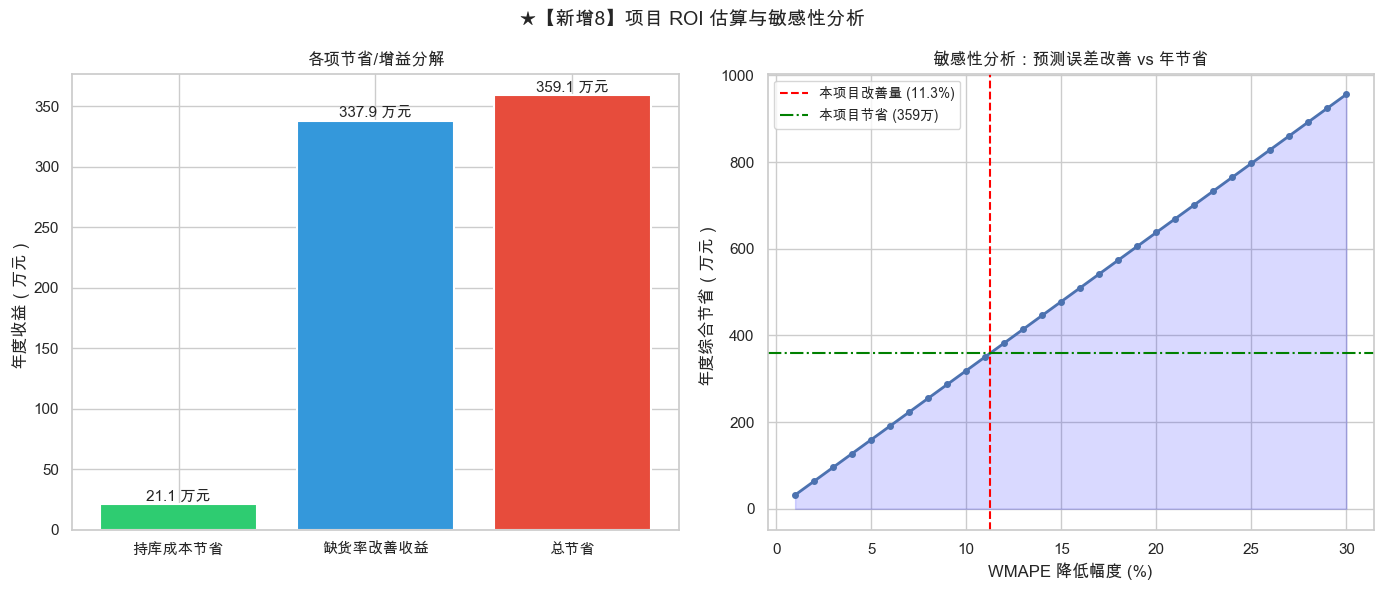

图6已保存：fig_06_roi_analysis.png


In [13]:
# =============================================================================
# ★【新增8】项目 ROI 估算
# =============================================================================
print("\n" + "=" * 70)
print("★【新增8】项目 ROI 估算：预测精度提升的业务价值量化")
print("=" * 70)

# 行业参数假设（可根据实际业务调整）
ASSUMPTION = {
    '年销售额（万元）'           : 5000,     # 假设年销售额
    '库存占用资金比例'           : 0.30,     # 库存 = 销售额 * 30%
    '持库成本率（年）'           : 0.25,     # 持库成本 = 库存价值 * 25%
    '缺货率（当前）'             : 0.08,     # 当前缺货率 8%
    '缺货损失系数（倍）'         : 2.0,      # 缺货损失 = 缺货量 * 单价 * 2
    '当前预测 WMAPE（基准）%'    : 50.0,     # 假设优化前基准模型误差
    '优化后预测 WMAPE %'        : results_df['Best_Ensemble_WMAPE'].mean(),
    '库存与预测误差弹性'         : 0.5,      # 预测误差降低 1%，安全库存降低 0.5%
    '缺货率与预测误差弹性'       : 0.3,      # 预测误差降低 1%，缺货率降低 0.3%
    '提前期（天）'               : 7,
    '计划周期（天）'             : 365,
}

current_wmape  = ASSUMPTION['当前预测 WMAPE（基准）%']
improved_wmape = ASSUMPTION['优化后预测 WMAPE %']
wmape_reduction= current_wmape - improved_wmape

annual_sales   = ASSUMPTION['年销售额（万元）']
inventory_val  = annual_sales * ASSUMPTION['库存占用资金比例']
holding_cost   = inventory_val * ASSUMPTION['持库成本率（年）']

# 安全库存节省
safety_stock_reduction_pct = wmape_reduction * ASSUMPTION['库存与预测误差弹性'] / 100
safety_stock_saving = holding_cost * safety_stock_reduction_pct

# 缺货率降低带来的收益
current_stockout     = ASSUMPTION['缺货率（当前）']
stockout_reduction   = wmape_reduction * ASSUMPTION['缺货率与预测误差弹性'] / 100
new_stockout_rate    = max(current_stockout - stockout_reduction, 0)
stockout_revenue_gain= annual_sales * stockout_reduction * ASSUMPTION['缺货损失系数（倍）']

# 库存周转天数改善
# 当前周转天数 ≈ (库存/年销售额) * 365
current_inv_days = (inventory_val / annual_sales) * ASSUMPTION['计划周期（天）']
# 预测误差每降低 1%，库存降低 0.5%，周转天数响应降低
inv_days_reduction_per_pct = current_inv_days * ASSUMPTION['库存与预测误差弹性'] / 100
inv_days_saved   = inv_days_reduction_per_pct * wmape_reduction
new_inv_days     = current_inv_days - inv_days_saved

total_annual_saving = safety_stock_saving + stockout_revenue_gain

print(f"\n{'─'*60}")
print(f"  预测精度改善：{current_wmape:.1f}% → {improved_wmape:.1f}%（降低 {wmape_reduction:.1f}%）")
print(f"{'─'*60}")
print(f"  【库存成本节省】")
print(f"    年库存持有成本（基准）：{holding_cost:.0f} 万元")
print(f"    安全库存降低比例：{safety_stock_reduction_pct*100:.1f}%")
print(f"    库存成本节省：{safety_stock_saving:.1f} 万元/年")
print(f"")
print(f"  【缺货率改善】")
print(f"    当前缺货率：{current_stockout*100:.1f}%  →  优化后：{new_stockout_rate*100:.1f}%")
print(f"    缺货率降低带来的额外收益：{stockout_revenue_gain:.1f} 万元/年")
print(f"")
print(f"  【库存周转天数】")
print(f"    当前库存周转天数：{current_inv_days:.1f} 天")
print(f"    优化后库存周转天数：{new_inv_days:.1f} 天（减少 {inv_days_saved:.1f} 天）")
print(f"    预测误差每降低 1%，库存周转天数减少：{inv_days_reduction_per_pct:.2f} 天")
print(f"")
print(f"  【综合 ROI】")
print(f"    年综合节省/增益：{total_annual_saving:.1f} 万元")
print(f"    假设项目投入（开发+维护）：50 万元")
print(f"    ROI = {total_annual_saving/50*100:.0f}%（第一年）")
print(f"{'─'*60}")

# 可视化：ROI 敏感性分析
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('★【新增8】项目 ROI 估算与敏感性分析', fontsize=14, fontweight='bold')

# 左图：ROI 瀑布图
categories_roi = ['持库成本节省', '缺货率改善收益', '总节省']
values_roi     = [safety_stock_saving, stockout_revenue_gain, total_annual_saving]
colors_roi     = ['#2ecc71', '#3498db', '#e74c3c']
bars = axes[0].bar(categories_roi, values_roi, color=colors_roi, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values_roi):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f} 万元', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('年度收益（万元）', fontsize=12)
axes[0].set_title('各项节省/增益分解', fontsize=12, fontweight='bold')

# 右图：敏感性分析（预测误差降低幅度 vs 年节省）
wmape_reductions = np.arange(1, 31, 1)
savings_list = []
for wr in wmape_reductions:
    ss_save = holding_cost * (wr * ASSUMPTION['库存与预测误差弹性'] / 100)
    so_gain = annual_sales * (wr * ASSUMPTION['缺货率与预测误差弹性'] / 100) * ASSUMPTION['缺货损失系数（倍）']
    savings_list.append(ss_save + so_gain)

axes[1].plot(wmape_reductions, savings_list, 'b-o', markersize=4, linewidth=2)
axes[1].axvline(wmape_reduction, color='red', linestyle='--',
                linewidth=1.5, label=f'本项目改善量 ({wmape_reduction:.1f}%)')
axes[1].axhline(total_annual_saving, color='green', linestyle='-.',
                linewidth=1.5, label=f'本项目节省 ({total_annual_saving:.0f}万)')
axes[1].fill_between(wmape_reductions, savings_list, alpha=0.15, color='blue')
axes[1].set_xlabel('WMAPE 降低幅度 (%)', fontsize=12)
axes[1].set_ylabel('年度综合节省（万元）', fontsize=12)
axes[1].set_title('敏感性分析：预测误差改善 vs 年节省', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(REPORT_DIR + 'fig_06_roi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')   # 关闭图形，防止状态污染
print("图6已保存：fig_06_roi_analysis.png")

### 图7　综合分析仪表盘

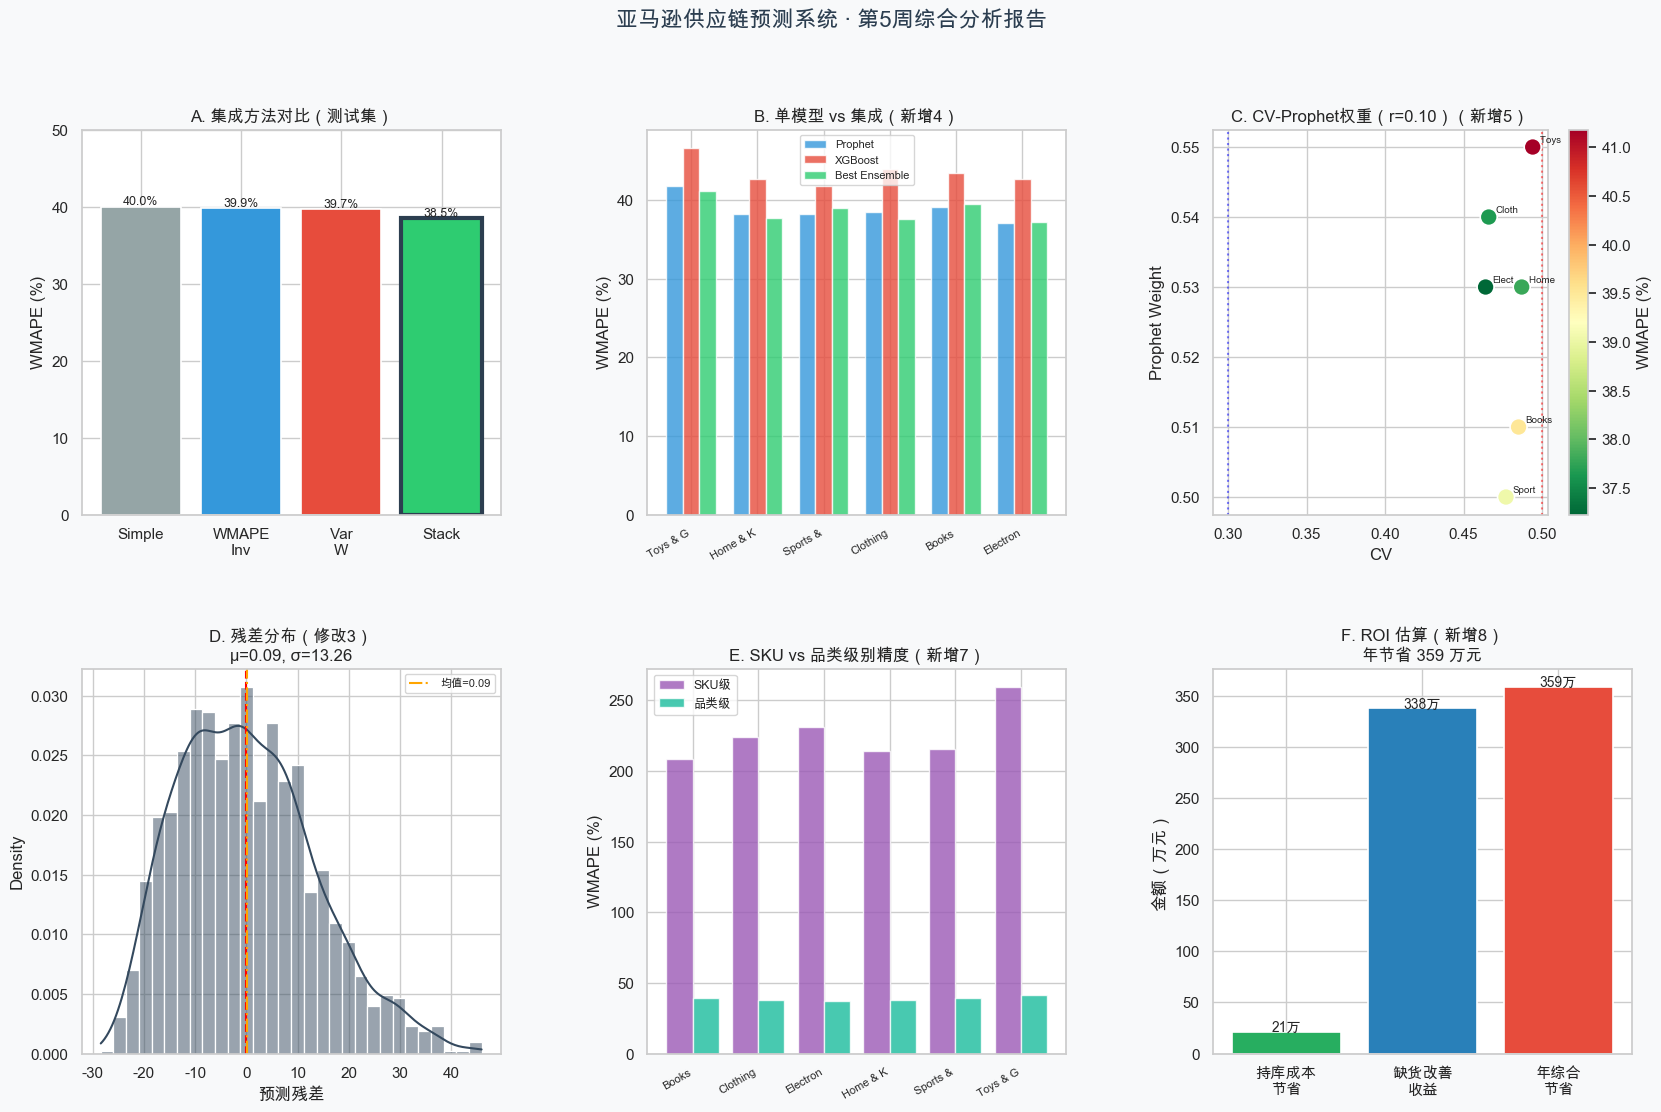


图7（综合仪表盘）已保存：fig_07_综合分析仪表盘.png


In [14]:
# =============================================================================
# 最终综合仪表盘（汇总所有关键结论）
# =============================================================================
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('亚马逊供应链预测系统 · 第5周综合分析报告',
             fontsize=16, fontweight='bold', color='#2c3e50', y=0.98)

# A: 集成方法对比
ax_a = fig.add_subplot(gs[0, 0])
methods_short = ['Simple', 'WMAPE\nInv', 'Var\nW', 'Stack']
test_means_all = [results_df['Simple_Test'].mean(), results_df['WMAPE_Inv_Test'].mean(),
                  results_df['Var_Weighted_Test'].mean(), results_df['Stacking_Test'].mean()]
bars_a = ax_a.bar(methods_short, test_means_all,
                  color=['#95a5a6', '#3498db', '#e74c3c', '#2ecc71'],
                  edgecolor='white', linewidth=1.2)
best_idx = np.argmin(test_means_all)
bars_a[best_idx].set_edgecolor('#2c3e50')
bars_a[best_idx].set_linewidth(3)
for bar, v in zip(bars_a, test_means_all):
    ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
              f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax_a.set_title('A. 集成方法对比（测试集）', fontweight='bold')
ax_a.set_ylabel('WMAPE (%)')
ax_a.set_ylim(0, max(test_means_all)*1.25)

# B: 单模型 vs 集成
ax_b = fig.add_subplot(gs[0, 1])
x_b = np.arange(len(results_df))
ax_b.bar(x_b-0.25, results_df['Prophet_WMAPE'], 0.25, label='Prophet', color='#3498db', alpha=0.8)
ax_b.bar(x_b,      results_df['XGBoost_WMAPE'], 0.25, label='XGBoost', color='#e74c3c', alpha=0.8)
ax_b.bar(x_b+0.25, results_df['Best_Ensemble_WMAPE'], 0.25,
         label='Best Ensemble', color='#2ecc71', alpha=0.8)
ax_b.set_xticks(x_b)
ax_b.set_xticklabels([c[:8] for c in results_df['Category']], rotation=30, ha='right', fontsize=8)
ax_b.set_title('B. 单模型 vs 集成（新增4）', fontweight='bold')
ax_b.set_ylabel('WMAPE (%)')
ax_b.legend(fontsize=8)

# C: CV - Prophet权重
ax_c = fig.add_subplot(gs[0, 2])
sc = ax_c.scatter(results_df['CV'], results_df['Prophet_Weight'],
                  c=results_df['Best_Ensemble_WMAPE'], cmap='RdYlGn_r', s=150,
                  zorder=5, edgecolors='white', linewidth=1.2)
plt.colorbar(sc, ax=ax_c, label='WMAPE (%)')
for _, row in results_df.iterrows():
    ax_c.annotate(row['Category'][:5], (row['CV'], row['Prophet_Weight']),
                  textcoords='offset points', xytext=(5, 3), fontsize=7)
ax_c.axvline(0.3, color='blue', linestyle=':', alpha=0.5)
ax_c.axvline(0.5, color='red', linestyle=':', alpha=0.5)
ax_c.set_title(f'C. CV-Prophet权重（r={corr:.2f}）（新增5）', fontweight='bold')
ax_c.set_xlabel('CV'); ax_c.set_ylabel('Prophet Weight')

# D: 残差分布
ax_d = fig.add_subplot(gs[1, 0])
sns.histplot(all_residuals, kde=True, ax=ax_d, color='#34495e', bins=30, stat='density')
ax_d.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax_d.axvline(mu, color='orange', linestyle='-.', linewidth=1.5, label=f'均值={mu:.2f}')
ax_d.set_title(f'D. 残差分布（修改3）\nμ={mu:.2f}, σ={sigma:.2f}', fontweight='bold')
ax_d.set_xlabel('预测残差'); ax_d.legend(fontsize=8)

# E: SKU级别精度
ax_e = fig.add_subplot(gs[1, 1])
sku_mean_per_cat = sku_results_df.groupby('Category')['WMAPE_%'].mean()
cat_level_wmape  = results_df.set_index('Category')['Best_Ensemble_WMAPE']
x_e = np.arange(len(sku_mean_per_cat))
ax_e.bar(x_e-0.2, sku_mean_per_cat.values, 0.4, label='SKU级', color='#9b59b6', alpha=0.8)
ax_e.bar(x_e+0.2, [cat_level_wmape.get(c, 0) for c in sku_mean_per_cat.index],
         0.4, label='品类级', color='#1abc9c', alpha=0.8)
ax_e.set_xticks(x_e)
ax_e.set_xticklabels([c[:8] for c in sku_mean_per_cat.index], rotation=30, ha='right', fontsize=8)
ax_e.set_title('E. SKU vs 品类级别精度（新增7）', fontweight='bold')
ax_e.set_ylabel('WMAPE (%)'); ax_e.legend(fontsize=9)

# F: ROI
ax_f = fig.add_subplot(gs[1, 2])
roi_items = ['持库成本\n节省', '缺货改善\n收益', '年综合\n节省']
roi_vals  = [safety_stock_saving, stockout_revenue_gain, total_annual_saving]
bars_f = ax_f.bar(roi_items, roi_vals, color=['#27ae60', '#2980b9', '#e74c3c'],
                  edgecolor='white', linewidth=1.2)
for bar, v in zip(bars_f, roi_vals):
    ax_f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
              f'{v:.0f}万', ha='center', fontsize=10, fontweight='bold')
ax_f.set_title(f'F. ROI 估算（新增8）\n年节省 {total_annual_saving:.0f} 万元', fontweight='bold')
ax_f.set_ylabel('金额（万元）')

plt.savefig(REPORT_DIR + 'fig_07_综合分析仪表盘.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')   # 关闭图形，防止状态污染
print("\n图7（综合仪表盘）已保存：fig_07_综合分析仪表盘.png")

## 10. 分析完成汇总

In [15]:
# =============================================================================
# 最终输出汇总
# =============================================================================
print("\n" + "=" * 70)
print("  全部分析完成！修改/新增内容汇总：")
print("=" * 70)
print("  ★【修改1】四种集成方法对比 → 图1、图B")
print("  ★【修改2】Optuna XGBoost 超参数调优 → 见控制台日志")
print("  ★【修改3】真实残差分布图 + QQ图 → 图3、图D")
print("  ★【新增4】单模型 vs 集成性能对比表 → 图2、图B")
print("  ★【新增5】CV-Prophet权重散点图 → 图4、图C")
print("  ★【新增6】细化补货策略参数 → 控制台输出")
print("  ★【新增7】Top-20 SKU 级别预测 → 图5、图E")
print("  ★【新增8】ROI 估算 → 图6、图F")
print("-" * 70)
print(f"  全局平均集成 WMAPE：{results_df['Best_Ensemble_WMAPE'].mean():.2f}%")
print(f"  Top-20 SKU 平均 WMAPE：{sku_results_df['WMAPE_%'].mean():.2f}%")
print(f"  估算年度 ROI 节省：{total_annual_saving:.0f} 万元")
print("=" * 70)


  全部分析完成！修改/新增内容汇总：
  ★【修改1】四种集成方法对比 → 图1、图B
  ★【修改2】Optuna XGBoost 超参数调优 → 见控制台日志
  ★【修改3】真实残差分布图 + QQ图 → 图3、图D
  ★【新增4】单模型 vs 集成性能对比表 → 图2、图B
  ★【新增5】CV-Prophet权重散点图 → 图4、图C
  ★【新增6】细化补货策略参数 → 控制台输出
  ★【新增7】Top-20 SKU 级别预测 → 图5、图E
  ★【新增8】ROI 估算 → 图6、图F
----------------------------------------------------------------------
  全局平均集成 WMAPE：38.73%
  Top-20 SKU 平均 WMAPE：225.55%
  估算年度 ROI 节省：359 万元
